# Understanding Descriptive Statistics

Import the necessary libraries here:

In [3]:
import pandas as pd              
import numpy as np
from scipy.stats import trim_mean  
from statsmodels import robust     
import wquantiles              
import random
import seaborn as sns
import matplotlib.pylab as plt

## Challenge 1
#### 1.- Define a function that simulates rolling a dice 10 times. Save the information in a dataframe.
**Hint**: you can use the *choices* function from module *random* to help you with the simulation.

In [18]:
lanzamientos = 10

In [17]:

def simular_lanzamiento_dado(lanzamientos):
    # Simular los lanzamientos del dado
    resultados = random.choices(range(1, 7), k=n_lanzamientos)
    
    # Crear un DataFrame con los resultados
    df = pd.DataFrame(resultados, columns=['Resultado'])
    
    return df



In [21]:
df_lanzamientos = simular_lanzamiento_dado(lanzamientos)

In [22]:
df_lanzamientos

,Resultado
0,6
1,1
2,4
3,4
4,4
5,6
6,5
7,1
8,6
9,6


In [24]:
df_lanzamientos_sorted = df_lanzamientos.sort_values(by='Resultado')

#### 2.- Plot the results sorted by value.

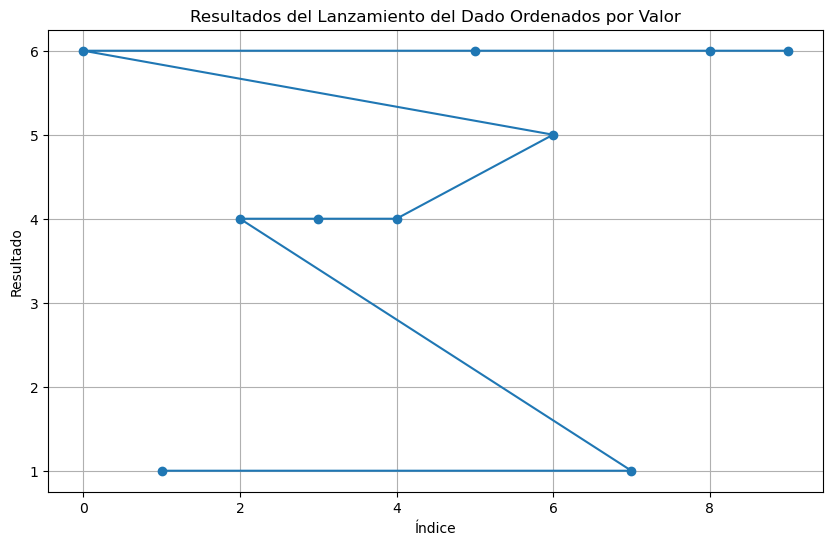

In [25]:
# Graficar los resultados ordenados
plt.figure(figsize=(10, 6))
plt.plot(df_lanzamientos_sorted['Resultado'], marker='o', linestyle='-')
plt.title('Resultados del Lanzamiento del Dado Ordenados por Valor')
plt.xlabel('Índice')
plt.ylabel('Resultado')
plt.grid(True)
plt.show()


#### 3.- Calculate the frequency distribution and plot it. What is the relation between this plot and the plot above? Describe it with words.

In [26]:
frecuencia = df_lanzamientos['Resultado'].value_counts().sort_index()
print(frecuencia)


Resultado
1    2
4    3
5    1
6    4
Name: count, dtype: int64


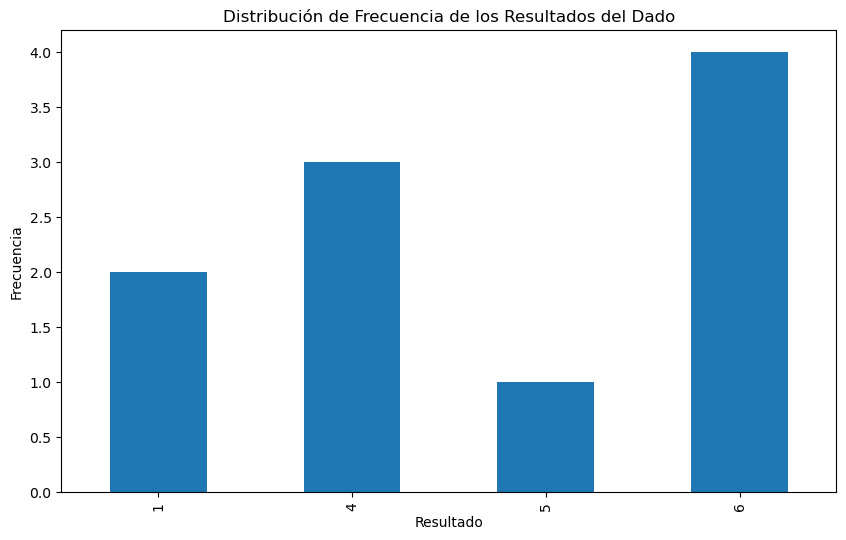

In [27]:
# Graficar la distribución de frecuencia
plt.figure(figsize=(10, 6))
frecuencia.plot(kind='bar')
plt.title('Distribución de Frecuencia de los Resultados del Dado')
plt.xlabel('Resultado')
plt.ylabel('Frecuencia')
plt.show()


In [ ]:
"""En resumen, esta distribución muestra que, en una pequeña muestra de lanzamientos,
algunos números pueden aparecer más frecuentemente que otros debido al azar.
Para obtener una visión más precisa de la distribución de los resultados,
sería útil realizar más lanzamientos y analizar una muestra más grande
El número 6 es el más frecuente, apareciendo 4 veces.
El número 5 es el menos frecuente, apareciendo solo 1 vez.
Los números 1 y 4 tienen frecuencias intermedias, apareciendo 2 y 3 veces respectivamente.

"""

## Challenge 2
Now, using the dice results obtained in *challenge 1*, your are going to define some functions that will help you calculate the mean of your data in two different ways, the median and the four quartiles. 

#### 1.- Define a function that computes the mean by summing all the observations and dividing by the total number of observations. You are not allowed to use any methods or functions that directly calculate the mean value. 

In [69]:
def calcular_media(df, columna):
    suma = 0
    n_observaciones = len(df[columna])
    
    for valor in df[columna]:
        suma += valor
    
    media = suma / n_observaciones
    return media




In [68]:
media = calcular_media(df_lanzamientos, 'Resultado')
print(f"La media es:",media)


La media es: 4.3


#### 2.- First, calculate the frequency distribution. Then, calculate the mean using the values of the frequency distribution you've just computed. You are not allowed to use any methods or functions that directly calculate the mean value. 

In [55]:
def calcular_media_frecuencia(frecuencia):
    suma = 0
    total_observaciones = 0
    
    for valor, freq in frecuencia.items():
        suma += valor * freq
        total_observaciones += freq
    
    media = suma / total_observaciones
    return media



La media es: 4.3


In [58]:
# Calcular la media utilizando la distribución de frecuencia
media = calcular_media_frecuencia(frecuencia)
print("La media es:",media)


La media es: 4.3


#### 3.- Define a function to calculate the median. You are not allowed to use any methods or functions that directly calculate the median value. 
**Hint**: you might need to define two computation cases depending on the number of observations used to calculate the median.

In [59]:
def calcular_mediana(df, columna):
    # Ordenar los valores de la columna
    valores_ordenados = df[columna].sort_values().reset_index(drop=True)
    n_observaciones = len(valores_ordenados)
    
    # Caso 1: Número impar de observaciones
    if n_observaciones % 2 != 0:
        mediana = valores_ordenados[n_observaciones // 2]
    # Caso 2: Número par de observaciones
    else:
        mediana = (valores_ordenados[(n_observaciones // 2) - 1] + valores_ordenados[n_observaciones // 2]) / 2
    
    return mediana



In [67]:
mediana = calcular_mediana(df_lanzamientos,"Resultado")
print("La mediana es:", mediana)

La mediana es: 4.5


#### 4.- Define a function to calculate the four quartiles. You can use the function you defined above to compute the median but you are not allowed to use any methods or functions that directly calculate the quartiles. 

In [71]:
def calcular_cuartiles(df, columna):
    valores_ordenados = df[columna].sort_values().reset_index(drop=True)
    n_observaciones = len(valores_ordenados)
    
    # Calcular Q2 (mediana)
    Q2 = calcular_mediana(valores_ordenados)
    
    # Calcular Q1 (primer cuartil)
    if n_observaciones % 2 == 0:
        Q1 = calcular_mediana(valores_ordenados[:n_observaciones // 2])
    else:
        Q1 = calcular_mediana(valores_ordenados[:n_observaciones // 2])
    
    # Calcular Q3 (tercer cuartil)
    if n_observaciones % 2 == 0:
        Q3 = calcular_mediana(valores_ordenados[n_observaciones // 2:])
    else:
        Q3 = calcular_mediana(valores_ordenados[(n_observaciones // 2) + 1:])
    
    # Calcular Q0 (mínimo) y Q4 (máximo)
    Q0 = valores_ordenados.iloc[0]
    Q4 = valores_ordenados.iloc[-1]
    
    return Q0, Q1, Q2, Q3, Q4




In [73]:
cuartiles = calcular_cuartiles(df_lanzamientos,"Resultado")
print("los cuartiles son:",cuartiles)

los cuartiles son: (1, 4, 4.5, 6, 6)


## Challenge 3
Read the csv `roll_the_dice_hundred.csv` from the `data` folder.
#### 1.- Sort the values and plot them. What do you see?

In [76]:
roll = pd.read_csv("../data/roll_the_dice_hundred.csv")


In [77]:
roll 

,Unnamed: 0,roll,value
0,0,0,1
1,1,1,2
2,2,2,6
3,3,3,1
4,4,4,6
...,...,...,...
95,95,95,4
96,96,96,6
97,97,97,1
98,98,98,3


In [79]:
roll_sorted = roll.sort_values(by='value')

In [80]:
roll_sorted 

,Unnamed: 0,roll,value
0,0,0,1
47,47,47,1
56,56,56,1
9,9,9,1
73,73,73,1
...,...,...,...
17,17,17,6
11,11,11,6
24,24,24,6
21,21,21,6


In [83]:
roll_sorted.describe()

,Unnamed: 0,roll,value
count,100.000000,100.000000,100.000000
mean,49.500000,49.500000,3.740000
std,29.011492,29.011492,1.703354
min,0.000000,0.000000,1.000000
25%,24.750000,24.750000,2.000000
50%,49.500000,49.500000,4.000000
75%,74.250000,74.250000,5.000000
max,99.000000,99.000000,6.000000


In [ ]:
"""
your comments here
"""

#### 2.- Using the functions you defined in *challenge 2*, calculate the mean value of the hundred dice rolls.

In [87]:
calcular_media(roll,"value")

3.74

#### 3.- Now, calculate the frequency distribution.


In [93]:
frecuencia_roll = roll['value'].value_counts().sort_index()


In [94]:
frecuencia_roll

value
1    12
2    17
3    14
4    22
5    12
6    23
Name: count, dtype: int64

#### 4.- Plot the histogram. What do you see (shape, values...) ? How can you connect the mean value to the histogram? 

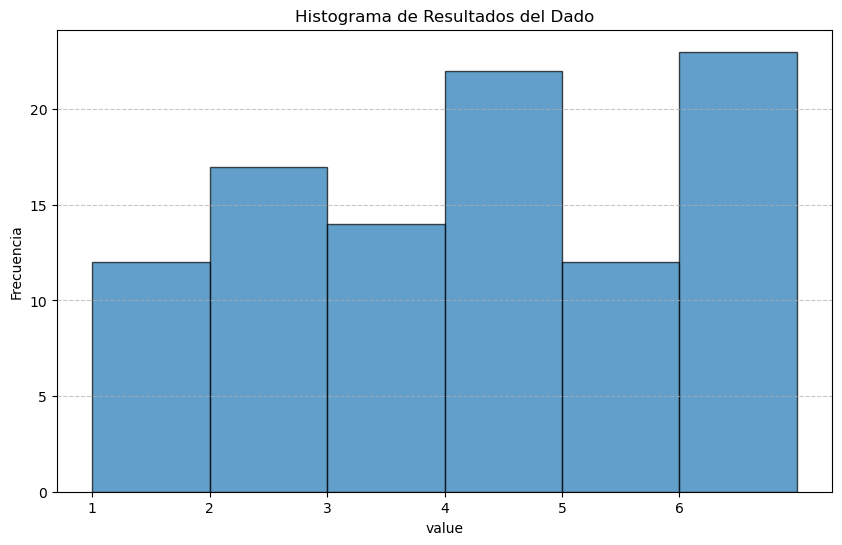

In [90]:
# Graficar el histograma
plt.figure(figsize=(10, 6))
plt.hist(roll['value'], bins=range(1, 8), edgecolor='black', alpha=0.7)
plt.title('Histograma de Resultados del Dado')
plt.xlabel('value')
plt.ylabel('Frecuencia')
plt.xticks(range(1, 7))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
"""
Podemos observar que los datos estan mucho mejor distribuidos en todas opciones
y podriamos asumir que ese comportamiento se debe a que tienen las misma probabilidades de salir
cada una de las opcines entre mas pruebas hagas mas destribuiran los casos en cada una de las opcines
"""

#### 5.- Read the `roll_the_dice_thousand.csv` from the `data` folder. Plot the frequency distribution as you did before. Has anything changed? Why do you think it changed?

In [96]:
roll_2 = pd.read_csv("../data/roll_the_dice_thousand.csv")

In [95]:
roll_2

,Unnamed: 0,roll,value
0,0,0,5
1,1,1,6
2,2,2,1
3,3,3,6
4,4,4,5
...,...,...,...
995,995,995,1
996,996,996,4
997,997,997,4
998,998,998,3


In [97]:
media_roll_2 = calcular_media(roll_2,"value")
print("la media es:",media_roll_2)

la media es: 3.447


In [99]:
frecuencia_roll_2 = roll_2['value'].value_counts().sort_index()
frecuencia_roll_2

value
1    175
2    167
3    175
4    168
5    149
6    166
Name: count, dtype: int64

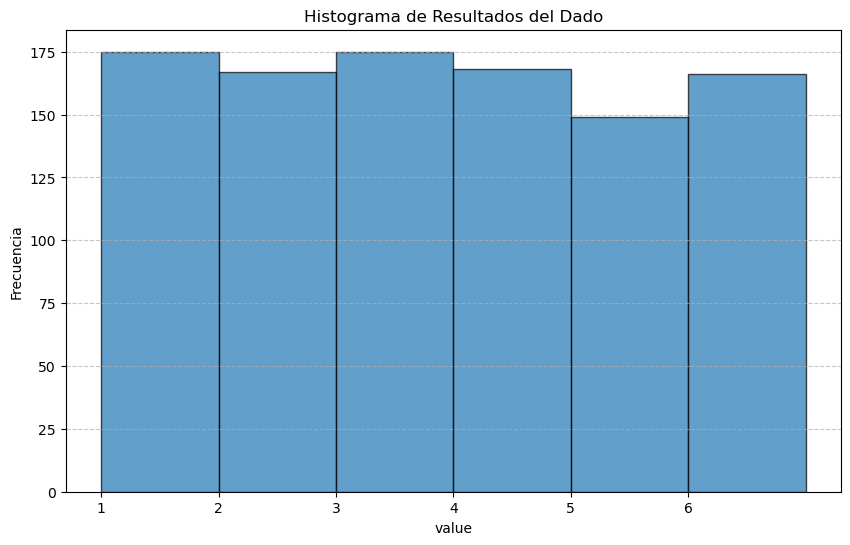

In [100]:
# Graficar el histograma
plt.figure(figsize=(10, 6))
plt.hist(roll_2['value'], bins=range(1, 8), edgecolor='black', alpha=0.7)
plt.title('Histograma de Resultados del Dado')
plt.xlabel('value')
plt.ylabel('Frecuencia')
plt.xticks(range(1, 7))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
"""
Podemos observar que se cumple lo esperado mientras mas casos de estudios tenemos una distribucion
casi uniforme. concluimos que son variables con las misma probabilidad de salir en el estudio 
"""

## Challenge 4
In the `data` folder of this repository you will find three different files with the prefix `ages_population`. These files contain information about a poll answered by a thousand people regarding their age. Each file corresponds to the poll answers in different neighbourhoods of Barcelona.

#### 1.- Read the file `ages_population.csv`. Calculate the frequency distribution and plot it as we did during the lesson. Try to guess the range in which the mean and the standard deviation will be by looking at the plot. 

In [105]:
ages_population = pd.read_csv("../data/ages_population.csv")

In [122]:
ages_population

,observation
0,68.0
1,12.0
2,45.0
3,38.0
4,49.0
...,...
995,27.0
996,47.0
997,53.0
998,33.0


In [125]:
# Obtener los valores únicos de la columna 'age'
edades_unicas = ages_population['observation'].unique()

# Mostrar el número de opciones de edades
num_opciones_edades = len(edades_unicas)
print("El número de opciones de edades es:",num_opciones_edades)

# Mostrar las edades únicas
print(edades_unicas)


El número de opciones de edades es: 72
[68. 12. 45. 38. 49. 27. 39. 42. 33. 30. 25. 44. 53. 46. 50. 22.  6. 29.
 35. 28. 26. 60. 41. 52. 32. 23. 15. 40. 63. 31. 34. 61. 64. 37. 56. 14.
 13. 51. 36. 18. 48. 58. 20. 54. 19. 62. 55. 21. 43. 17.  7. 47.  1. 16.
 24. 59. 57.  8. 67.  2. 66.  4. 73. 82. 70.  5. 71.  9. 69. 11. 10. 65.]


In [108]:
frecuencia_ages_population = ages_population['observation'].value_counts().sort_index()
frecuencia_ages_population

observation
1.0     2
2.0     2
4.0     1
5.0     2
6.0     2
       ..
69.0    1
70.0    1
71.0    1
73.0    1
82.0    1
Name: count, Length: 72, dtype: int64

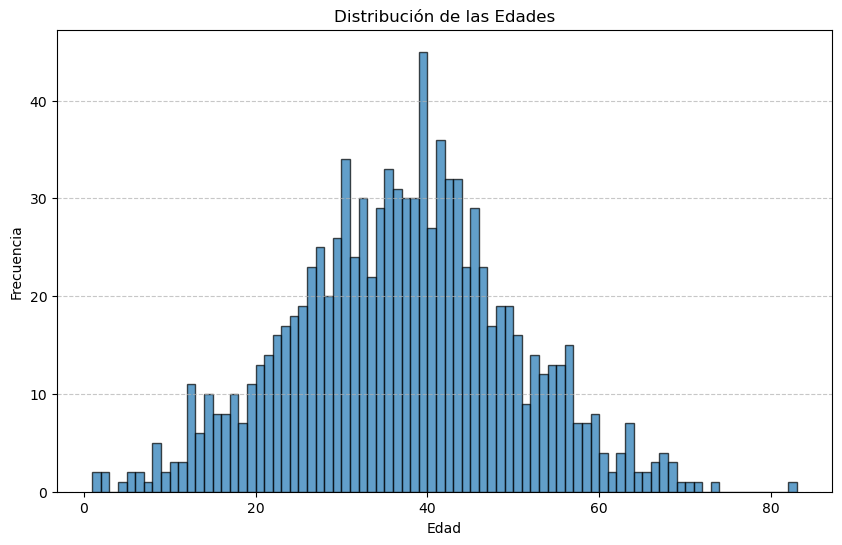

In [132]:
# Graficar el histograma de las edades
plt.figure(figsize=(10, 6))
plt.hist(ages_population['observation'], bins=range(int(age_population['observation'].min()), int(age_population['observation'].max()) + 2), edgecolor='black', alpha=0.7)
plt.title('Distribución de las Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### 2.- Calculate the exact mean and standard deviation and compare them with your guesses. Do they fall inside the ranges you guessed?

In [136]:
# Calcular la media
media = ages_population['observation'].mean()
print(f"La media exacta es:",media)


La media exacta es: 36.56


In [139]:
# Calcular la desviación estándar
desviacion_estandar = ages_population['observation'].std()
print("La desviación estándar exacta es:" ,desviacion_estandar)


La desviación estándar exacta es: 12.816499625976762


In [140]:
rango = ages_population['observation'].max() - ages_population['observation'].min() 
print("El rango es:",rango)

El rango es: 81.0


In [ ]:
"""
your comments here
"""

#### 3.- Now read the file `ages_population2.csv` . Calculate the frequency distribution and plot it.

In [ ]:
# your code here

####  4.- What do you see? Is there any difference with the frequency distribution in step 1?

In [ ]:
"""
your comments here
"""

#### 5.- Calculate the mean and standard deviation. Compare the results with the mean and standard deviation in step 2. What do you think?

In [ ]:
# your code here

In [ ]:
"""
your comments here
"""

## Challenge 5
Now is the turn of `ages_population3.csv`.

#### 1.- Read the file `ages_population3.csv`. Calculate the frequency distribution and plot it.

In [ ]:
# your code here

#### 2.- Calculate the mean and standard deviation. Compare the results with the plot in step 1. What is happening?

In [ ]:
# your code here

In [ ]:
"""
your comments here
"""

#### 3.- Calculate the four quartiles. Use the results to explain your reasoning for question in step 2. How much of a difference is there between the median and the mean?

In [ ]:
# your code here

In [ ]:
"""
your comments here
"""

#### 4.- Calculate other percentiles that might be useful to give more arguments to your reasoning.

In [ ]:
# your code here

In [ ]:
"""
your comments here
"""

## Bonus challenge
Compare the information about the three neighbourhoods. Prepare a report about the three of them. Remember to find out which are their similarities and their differences backing your arguments in basic statistics.

In [ ]:
# your code here

In [ ]:
"""
your comments here
"""